# Wiskunde II — Portfolio-opdracht: CO₂-uitstoot en mobiliteit

**Groep 25:** Melih Bağci · Jafari Deul · Thomas Keus

**Deadline notebook (Brightspace):** zondag 21 juni, 23:59 — voorwaardelijk voor het assessment.

**Handgeschreven verslag:** 1 per groep, inleveren bij het assessment. Alle verslagvragen staan verzameld in het hoofdstuk **Verslag** onderaan dit notebook. Daar werken we de antwoorden samen uit; 1 persoon schrijft ze daarna over op papier.

## Hoofdvragen van het portfolio
1. Welke persoonlijke en mobiliteitsgerelateerde factoren verklaren verschillen in de jaarlijkse CO₂-uitstoot tussen burgers?
2. In welke mate kunnen we individuele uitstoot nauwkeurig voorspellen op basis van een combinatie van sociaaldemografische kenmerken en mobiliteitsgedrag?

## Taakverdeling

| Deel | Onderwerp | Python-opdrachten | Verslagvragen | Wie |
|---|---|---|---|---|
| 0 | Setup & data inladen | — | — | samen |
| 1 | Beschrijvende statistiek & opschonen | A, B | 1, 2, 3 | **Melih** |
| 2 | Verdelingen & normaliteit | C, D | 4, 5 | **Melih** |
| 3 | Transformatie & relaties | E, F | 6, 7, 8 | **Jafari** |
| 4 | Kansrekening | G | 9 | **Jafari** |
| 5 | Hypothesetoetsing (groepsverschil) | H, I | 10–14 | **Jafari** |
| 6 | Lineaire regressie | J, K, L | 15, 16, 17 | **Thomas** |
| 7 | Modelvergelijking (20-fold CV) | M, N, O, P | 18, 19 | **Thomas** |
| 8 | Classificatie | Q, R | 20, 21 | **Melih** |
| 9 | Conclusie | — | 22 | samen |

Wie een deel doet, vult ook de bijbehorende verslagvragen in (hoofdstuk **Verslag** onderaan). 1 persoon schrijft het verslag daarna handgeschreven uit.

**Assessment:** ieder krijgt 5 vragen, 1 per leerdoel, over het hele portfolio. Iedereen moet dus alle delen begrijpen. Plan een gezamenlijke doorloopsessie voor het assessment.

### Leerdoelen (beoordelingsmodel, max 50 punten)
1. Beschrijvende statistieken berekenen en interpreteren (10 pt) — Deel 1
2. Correlatie & regressie opstellen en interpreteren (10 pt) — Deel 3, 6
3. Regels van kansrekening toepassen (5 pt) — Deel 4, vraag 15
4. Verdeling visualiseren en interpreteren (10 pt) — Deel 2, 5, 7
5. Geschikte statistische toets kiezen, uitvoeren, interpreteren (15 pt) — Deel 2, 5, 7

---
## Deel 0 — Setup & data inladen *(samen)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_excel("Mobiliteitsdata.xlsx")
print(df.shape)
df.head()

(1500, 22)


,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,stad,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Almere,Flevoland,MBO,ja,ja,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Leeuwarden,Overijssel,WO,ja,nee,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Tilburg,Utrecht,HBO,ja,ja,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Maastricht,Utrecht,HBO,ja,ja,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Leiden,Gelderland,MBO,ja,ja,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


---
## Deel 1 — Beschrijvende statistiek & opschonen *(Melih)*

### A — Bepaal voor elke kolom de relevante beschrijvende statistieken
*Relevant = passend bij het meetniveau: numeriek → gemiddelde, mediaan, std, kwartielen, min/max; categoriaal → frequenties/modus.*

In [2]:
# TODO (Melih): numerieke kolommen
df.describe()

,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.000000,1500.000000,1500.00000,1499.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1493.000000
mean,560229.090000,47.989333,75.14630,40092.551094,3.032000,8597.262393,1794.180353,2942.222840,1072.277327,2.532667,2.467333,14.485333,4912.341875
std,260939.294996,18.134915,14.79674,14986.839768,1.411017,7021.428530,753.991154,1531.377214,748.651072,1.671365,1.671365,8.700819,3422.902397
min,102295.000000,0.000000,0.00000,-8505.150000,1.000000,-6506.630000,0.000000,-2264.780000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,332525.750000,32.000000,65.63500,30008.920000,2.000000,0.000000,1503.420000,1950.682500,471.540000,1.000000,1.000000,7.000000,1469.450000
50%,563847.000000,47.000000,75.79000,40503.080000,3.000000,9356.380000,1910.005000,2987.030000,1052.140000,3.000000,2.000000,15.000000,4677.280000
75%,792686.750000,64.000000,84.93500,50281.165000,4.000000,13842.732500,2286.180000,3991.537500,1588.555000,4.000000,4.000000,22.000000,7481.550000
max,999493.000000,79.000000,117.76000,93826.850000,5.000000,34618.870000,3672.700000,8018.060000,3808.200000,5.000000,5.000000,29.000000,18098.440000


In [3]:
# TODO (Melih): categoriale kolommen — frequenties per kolom
# bv.: for kol in df.select_dtypes(include="object"): print(df[kol].value_counts(), "\n")

### B — Missende / niet-kloppende / extreme waarden opsporen en adequaat afhandelen

Checklist:
- [ ] Missende waarden: `df.isna().sum()`
- [ ] Niet-kloppende waarden: stad/provincie-combinaties kloppen niet altijd (bv. rij met Leeuwarden in "Overijssel" — hoort Friesland te zijn). Check ook: negatieve km's, gewicht/leeftijd buiten realistische range, thuiswerk + kantoor > 5 dagen, km_auto > 0 terwijl autobezit = nee?
- [ ] Extreme waarden (outliers): boxplots / IQR-regel / z-scores
- [ ] Keuze documenteren: verwijderen, corrigeren of imputeren — en waarom (nodig voor verslagvraag 3)

In [4]:
# TODO (Melih): missende waarden
df.isna().sum()

persoon_ID                               0
geslacht                                 0
leeftijd                                 0
gewicht_KG                               0
burgerlijke_staat                        0
jaarsalaris_eu                           1
huishouden_grootte                       0
stad                                     1
provincie                                0
opleiding_niveau                         1
autobezit                                1
fietsbezit                               0
elektrisch_auto                          0
km_auto_per_jaar                         0
km_fiets_per_jaar                        0
km_ov_per_jaar                           0
km_vliegtuig_per_jaar                    0
dagen_thuiswerken_per_week_pro_rato      0
dagen_kantoorwerken_per_week_pro_rato    0
dagen_in_buitenland_per_jaar             0
gebruik_carsharing                       0
co2_uitstoot_per_jaar_KG                 7
dtype: int64

In [5]:
# TODO (Melih): niet-kloppende waarden
# tip: df.groupby("stad")["provincie"].value_counts() om stad/provincie-fouten te zien
# tip: (df["km_auto_per_jaar"] < 0).sum(), ranges van leeftijd/gewicht checken

In [6]:
# TODO (Melih): extreme waarden (boxplots / IQR / z-score)

In [7]:
# TODO (Melih): afhandeling → maak df_clean en werk vanaf hier daarmee verder
df_clean = df.copy()
# ... correcties hier ...
print(df_clean.shape)

(1500, 22)


---
## Deel 2 — Verdelingen & normaliteit *(Melih)*

### C — Kies 2 onafhankelijke variabelen met (verwachte) invloed op CO₂-uitstoot; visualiseer hun verdeling én die van de afhankelijke variabele
*Kies numerieke variabelen (bv. `km_auto_per_jaar` en `km_vliegtuig_per_jaar`) — dan kun je in D ook op normaliteit toetsen. Histogram + KDE per variabele = 3 plots.*

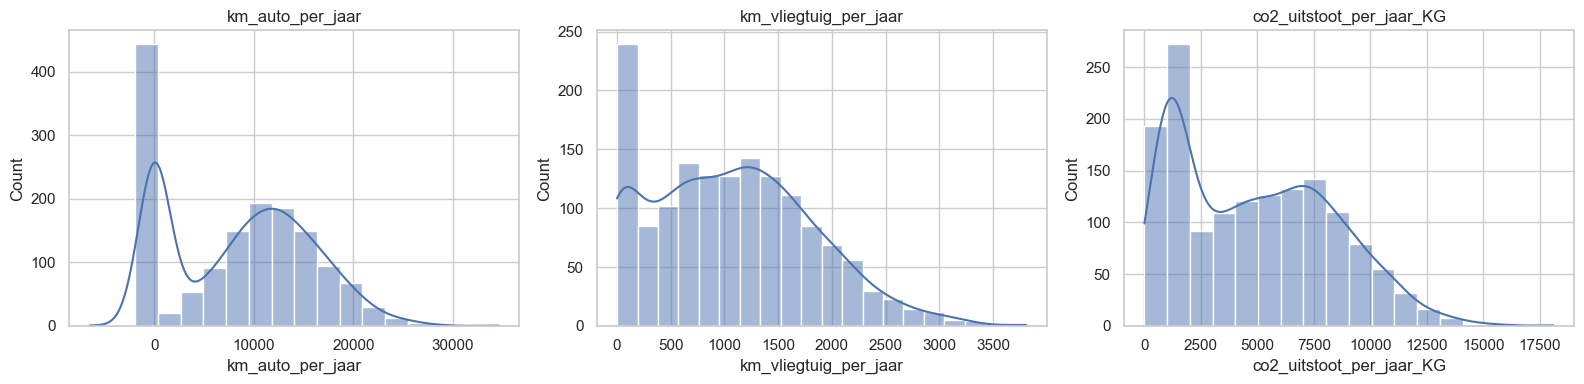

In [8]:
# TODO (Melih): keuze vastleggen
var1 = "km_auto_per_jaar"       # aanpassen indien gewenst
var2 = "km_vliegtuig_per_jaar"  # aanpassen indien gewenst
target = "co2_uitstoot_per_jaar_KG"

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, kol in zip(axes, [var1, var2, target]):
    sns.histplot(df_clean[kol], kde=True, ax=ax)
    ax.set_title(kol)
plt.tight_layout()
plt.show()

### D — Toets statistisch of de drie verdelingen normaal verdeeld zijn
*Bv. Shapiro-Wilk (`stats.shapiro`) of Kolmogorov-Smirnov; QQ-plots als visuele ondersteuning. H0: data is normaal verdeeld.*

In [9]:
# TODO (Melih): normaliteitstoets per variabele
for kol in [var1, var2, target]:
    stat, p = stats.shapiro(df_clean[kol])
    print(f"{kol}: W = {stat:.4f}, p = {p:.4g}")

km_auto_per_jaar: W = 0.9178, p = 8.353e-28
km_vliegtuig_per_jaar: W = 0.9654, p = 1.832e-18
co2_uitstoot_per_jaar_KG: W = nan, p = nan


In [10]:
# TODO (Melih, optioneel): QQ-plots ter ondersteuning
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# for ax, kol in zip(axes, [var1, var2, target]):
#     stats.probplot(df_clean[kol], dist="norm", plot=ax); ax.set_title(kol)

---
## Deel 3 — Transformatie & relaties *(Jafari)*

### E — Voer de transformatie voor Machine Learning uit (in een **nieuw** dataframe, origineel behouden!)
*Wat er per meetniveau moet gebeuren beschrijf je in verslagvraag 6.*

In [11]:
# TODO (Jafari): transformatie → df_ml
df_ml = df_clean.copy()

# 1) drop kolommen zonder voorspellende waarde (persoon_ID; stad evt. te veel categorieën?)
# 2) ordinaal coderen met behoud volgorde, bv.:
#    df_ml["opleiding_niveau"] = df_ml["opleiding_niveau"].map({...})
#    df_ml["gebruik_carsharing"] = df_ml["gebruik_carsharing"].map({...})
# 3) nominaal → dummies: pd.get_dummies(df_ml, columns=[...], drop_first=True)
# 4) ja/nee → 0/1

df_ml.head()

,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,stad,provincie,opleiding_niveau,autobezit,fietsbezit,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Almere,Flevoland,MBO,ja,ja,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Leeuwarden,Overijssel,WO,ja,nee,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Tilburg,Utrecht,HBO,ja,ja,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Maastricht,Utrecht,HBO,ja,ja,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Leiden,Gelderland,MBO,ja,ja,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


### F — Krijg inzicht in de relaties tussen alle variabelen
*Bv. correlatiematrix + heatmap op df_ml; eventueel pairplot van de belangrijkste variabelen.*

In [12]:
# TODO (Jafari): correlatiematrix + heatmap
# corr = df_ml.corr(numeric_only=True)
# plt.figure(figsize=(14, 11))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
# plt.show()

---
## Deel 4 — Kansrekening *(Jafari)*

### G — Wat is de kans dat een willekeurig persoon 5000 kg CO₂ uitstoot? Gebruik de **standaard normaalverdeling**
*Stappenplan: μ en σ van de uitstoot bepalen → z-score van 5000 berekenen → kans via `stats.norm`. Let op: bij een continue verdeling is P(X = exact 5000) ≈ 0; kies en onderbouw een interpretatie (P(X ≤ 5000), P(X ≥ 5000) of een klein interval) — beschrijf dit in verslagvraag 9.*

In [13]:
# TODO (Jafari)
mu = df_clean["co2_uitstoot_per_jaar_KG"].mean()
sigma = df_clean["co2_uitstoot_per_jaar_KG"].std()
z = (5000 - mu) / sigma
print(f"mu = {mu:.2f}, sigma = {sigma:.2f}, z = {z:.4f}")

# kans via standaardnormaal:
# stats.norm.cdf(z)        -> P(X <= 5000)
# 1 - stats.norm.cdf(z)    -> P(X >= 5000)

mu = 4912.34, sigma = 3422.90, z = 0.0256


---
## Deel 5 — Hypothesetoetsing: verschil tussen groepen *(Jafari)*

**Opdracht:** kies een categoriale variabele (minimaal 2 groepen, **niet geslacht**) en onderzoek of de CO₂-uitstoot verschilt tussen de groepen. Hypothesen, foutentypes en toetskeuze komen in verslagvragen 10–12.

**Onze keuze:** `…` *(bv. autobezit, elektrisch_auto of opleiding_niveau — bij meer dan 2 groepen wordt het ANOVA i.p.v. t-toets!)*

### H — Maak geschikte plots om het verschil tussen de groepen te visualiseren

In [14]:
# TODO (Jafari): keuze vastleggen + plots
groep_var = "autobezit"  # aanpassen naar definitieve keuze (niet geslacht!)

# bv. boxplot + histogrammen per groep:
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# sns.boxplot(data=df_clean, x=groep_var, y="co2_uitstoot_per_jaar_KG", ax=axes[0])
# sns.histplot(data=df_clean, x="co2_uitstoot_per_jaar_KG", hue=groep_var, kde=True, ax=axes[1])

### I — Voer de toets uit

In [15]:
# TODO (Jafari): eerst aannames checken (normaliteit per groep, evt. gelijke varianties via Levene),
# dan de toets:
# groepen = [g["co2_uitstoot_per_jaar_KG"].values for _, g in df_clean.groupby(groep_var)]
# stats.ttest_ind(*groepen)            # 2 groepen, normaal
# stats.mannwhitneyu(*groepen)         # 2 groepen, niet normaal
# stats.f_oneway(*groepen)             # > 2 groepen

---
## Deel 6 — Lineaire regressie *(Thomas)*

### J — Splits de data in een train- en testset (kies zelf een geschikte split)

In [16]:
# TODO (Thomas)
X = df_ml.drop(columns=["co2_uitstoot_per_jaar_KG"])
y = df_ml["co2_uitstoot_per_jaar_KG"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1200, 21) (300, 21)


In [ ]:
# Hulpberekening voor verslagvraag 15: aantal mogelijke splits
from math import comb
from decimal import Decimal
n = len(df_ml)
k = len(X_test)
aantal = comb(n, k)
# Decimal i.p.v. float: C(1500, 300) is veel groter dan een float aankan
print(f"C({n}, {k}) = {Decimal(aantal):.4e}")

### K — Train een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen

In [ ]:
# TODO (Thomas)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("intercept:", lr.intercept_)
coefs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefs

In [ ]:
# Hulpberekening voor verslagvraag 17: voorspelling voor 1 groepsgenoot
# TODO (Thomas): vul echte waarden van een groepsgenoot in (zelfde kolommen/encoding als X)
# groepsgenoot = pd.DataFrame([{...}])
# lr.predict(groepsgenoot)

### L — Bepaal welke 5 onafhankelijke variabelen de meeste invloed hebben op de voorspelling
*Let op: coëfficiënten zijn alleen vergelijkbaar als de features op dezelfde schaal staan → standaardiseer eerst (of train op gestandaardiseerde X) en kijk dan naar |coëfficiënt|.*

In [ ]:
# TODO (Thomas)
# scaler = StandardScaler()
# X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
# lr_s = LinearRegression().fit(X_train_s, y_train)
# top5 = pd.Series(lr_s.coef_, index=X.columns).abs().sort_values(ascending=False).head(5)
# top5_features = list(top5.index)
# top5

---
## Deel 7 — Modelvergelijking met 20-fold cross-validation *(Thomas)*

### M — Train en test 2 modellen met 20-fold cross-validation
*Model 1: alle variabelen · Model 2: alleen de top-5 variabelen uit L.*

In [ ]:
# TODO (Thomas)
# kf = KFold(n_splits=20, shuffle=True, random_state=42)
# scores_alle = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="...")  # scoring = metric uit verslagvraag 16
# scores_top5 = cross_val_score(LinearRegression(), X[top5_features], y, cv=kf, scoring="...")

### N — Kwantificeer de nauwkeurigheid van beide modellen met 1 metric (zie verslagvraag 16)

In [ ]:
# TODO (Thomas): gemiddelde + std van de 20 scores per model
# print(f"alle variabelen: {scores_alle.mean():.3f} ± {scores_alle.std():.3f}")
# print(f"top-5:           {scores_top5.mean():.3f} ± {scores_top5.std():.3f}")

### O — Visualiseer het verschil in nauwkeurigheid tussen de twee modellen
*Bv. boxplot of histogram van de 2 × 20 CV-scores naast elkaar.*

In [ ]:
# TODO (Thomas)

### P — Onderzoek met toetsende statistiek welk model significant beter is
*De 20 scores zijn gepaard (zelfde folds!) → gepaarde t-toets (`stats.ttest_rel`) als de verschillen normaal verdeeld zijn, anders Wilcoxon signed-rank (`stats.wilcoxon`). Check de normaliteit van de verschilscores eerst.*

In [ ]:
# TODO (Thomas)
# verschillen = scores_alle - scores_top5
# stats.shapiro(verschillen)
# stats.ttest_rel(scores_alle, scores_top5)  # of stats.wilcoxon(...)

---
## Deel 8 — Classificatie *(Melih)*

### Q — Splits de targetvariabele in 2 even grote klassen (0 = lage uitstoot, 1 = hoge uitstoot)
*Even grote klassen → afkapwaarde = mediaan.*

In [ ]:
# TODO (Melih)
afkap = df_ml["co2_uitstoot_per_jaar_KG"].median()
y_klasse = (df_ml["co2_uitstoot_per_jaar_KG"] > afkap).astype(int)
print(f"afkapwaarde (mediaan): {afkap:.2f}")
print(y_klasse.value_counts())

### R — Train een nieuw model op de nieuwe target met alleen de 5 invloedrijkste variabelen
*Modelkeuze onderbouw je in verslagvraag 20.*

In [ ]:
# TODO (Melih)
# Xc_train, Xc_test, yc_train, yc_test = train_test_split(X[top5_features], y_klasse, test_size=0.2, random_state=42)
# logr = LogisticRegression(max_iter=1000).fit(Xc_train, yc_train)
# print("accuracy:", logr.score(Xc_test, yc_test))
# print("intercept:", logr.intercept_, "coefs:", dict(zip(top5_features, logr.coef_[0])))

In [ ]:
# Hulpberekening voor verslagvraag 21: kans voor 1 groepsgenoot
# TODO (Melih): logr.predict_proba(groepsgenoot[top5_features])

---
# Verslag (handgeschreven, inleveren bij assessment)

Alle theorievragen op een rij. Vul je antwoord onder je eigen vragen in (zie taakverdeling); 1 persoon schrijft het geheel daarna leesbaar met de hand uit.

---

**Vraag 1 (Melih) — Geef voor elke variabele in de dataset weer tot welk meetniveau deze behoort.**
*(nominaal / ordinaal / interval / ratio)*

| Variabele | Meetniveau |
|---|---|
| persoon_ID | nominaal (label, geen meetwaarde) |
| geslacht | … |
| leeftijd | … |
| gewicht_KG | … |
| burgerlijke_staat | … |
| jaarsalaris_eu | … |
| huishouden_grootte | … |
| stad | … |
| provincie | … |
| opleiding_niveau | … (MBO < HBO < WO heeft een volgorde) |
| autobezit / fietsbezit / elektrisch_auto | … |
| km_auto / km_fiets / km_ov / km_vliegtuig per jaar | … |
| dagen_thuiswerken / dagen_kantoorwerken per week | … |
| dagen_in_buitenland_per_jaar | … |
| gebruik_carsharing | … (Nooit / Heel soms / … → volgorde?) |
| co2_uitstoot_per_jaar_KG | … |

**Vraag 2 (Melih) — Waarom is het nodig om vooraf het meetniveau van elke variabele te bekijken?**

> *Antwoord: … (denk aan: welke statistieken zijn toegestaan — gemiddelde van nominale data is zinloos; welke grafieken passen; welke toetsen mogen; welke ML-transformatie nodig is)*

**Vraag 3 (Melih) — Hoe ben je omgegaan met missende/niet-kloppende/extreme waarden in de dataset?** *(zie Python B)*

> *Antwoord: … (per type probleem: wat gevonden, welke keuze — verwijderen/corrigeren/imputeren — en waarom)*

**Vraag 4 (Melih) — Geef een beschrijving van de 3 visualisaties met behulp van statistische termen.** *(zie Python C)*

> *Antwoord: … (per verdeling: symmetrisch of scheef links/rechts, modaliteit, centrum gemiddelde vs. mediaan, spreiding, uitschieters)*

**Vraag 5 (Melih) — Wat is de conclusie met betrekking tot de drie verdelingen?** *(zie Python D)*

> *Antwoord: … (per variabele: p-waarde vs. α = 0,05 → H0 verwerpen of niet → wel/niet normaal verdeeld)*

**Vraag 6 (Jafari) — Om onafhankelijke variabelen te gebruiken voor Machine Learning moeten ze getransformeerd worden. Geef per meetniveau aan wat er moet gebeuren.**

> *Antwoord:*
> - *Nominaal → … (one-hot encoding / dummies)*
> - *Ordinaal → … (codering die de volgorde behoudt)*
> - *Interval/ratio → … (schalen/standaardiseren)*

**Vraag 7 (Jafari) — Wat kun je zeggen over de relaties tussen de variabelen?** *(zie Python F)*

> *Antwoord: … (welke variabelen correleren sterk met CO₂-uitstoot — richting + sterkte; onderlinge correlatie / multicollineariteit)*

**Vraag 8 (Jafari) — Welke methode(n) heb je gebruikt en waarom?**

> *Antwoord: … (Pearson — lineair, interval/ratio vs. Spearman — monotoon, ordinaal/niet-normaal; koppel aan conclusie vraag 5)*

**Vraag 9 (Jafari) — Geef een korte beschrijving van hoe je de kans op 5000 kg CO₂-uitstoot hebt berekend.** *(zie Python G)*

> *Antwoord: … (μ en σ → z-score → standaardnormaalverdeling → interpretatie van de gekozen kans)*

**Vraag 10 (Jafari) — Stel de hypothesen op.** *(groepsvergelijking, zie Deel 5)*

> *H0: …*
> *H1: …*

**Vraag 11 (Jafari) — Welke type fouten kunnen er gemaakt worden?**

> *Antwoord: … (Type I (α): H0 onterecht verwerpen → concreet voor onze situatie; Type II (β): H0 onterecht behouden → …)*

**Vraag 12 (Jafari) — Welke statistische toets moet je uitvoeren om te onderzoeken of er een significant verschil is?**

> *Antwoord: … (2 groepen + normaal → onafhankelijke t-toets; niet normaal → Mann-Whitney U; > 2 groepen → ANOVA / Kruskal-Wallis; onderbouw met normaliteitscheck per groep)*

**Vraag 13 (Jafari) — Geef in eigen woorden een toelichting op de betekenis van de p-waarde.**

> *Antwoord: … (de kans om — als H0 waar is — een resultaat te vinden dat minstens zo extreem is als het waargenomen resultaat; NIET de kans dat H0 waar is)*

**Vraag 14 (Jafari) — Welke conclusie kun je trekken op basis van de statistische toets?** *(zie Python I)*

> *Antwoord: … (p vs. α = 0,05 → H0 wel/niet verwerpen → betekenis voor de CO₂-uitstoot van de groepen)*

**Vraag 15 (Thomas) — Op hoeveel verschillende manieren kan de train/test-split gemaakt worden? Gebruik wetenschappelijke notatie.** *(zie hulpberekening bij Python J)*

> *Antwoord: … (combinatoriek: C(n, k) = n! / (k!(n−k)!) met n = …, k = … → a × 10^b)*

**Vraag 16 (Thomas) — Welke metric zou je gebruiken om te toetsen hoe goed je model is en waarom?**

> *Antwoord: … (R² — verklaarde variantie; MAE — gemiddelde absolute fout in kg, goed interpreteerbaar; RMSE — straft grote fouten zwaarder; kies + onderbouw)*

**Vraag 17 (Thomas) — Geef de wiskundige formule van het getrainde regressiemodel en pas deze toe op 1 groepsgenoot.** *(zie Python K + hulpberekening)*

> *Antwoord: ŷ = b0 + b1·x1 + b2·x2 + … met ingevulde coëfficiënten en de echte gegevens van een groepsgenoot → voorspelde uitstoot = … kg*

**Vraag 18 (Thomas) — Welke statistische toets(en) heb je gebruikt bij de modelvergelijking en waarom?** *(zie Python P)*

> *Antwoord: … (gepaard vs. ongepaard — waarom gepaard hier; normaliteitscheck van de verschilscores → keuze toets)*

**Vraag 19 (Thomas) — Wat is de conclusie van de statistische toets?**

> *Antwoord: … (p vs. α → wel/geen significant verschil → welk model kiezen we: eenvoud vs. nauwkeurigheid)*

**Vraag 20 (Melih) — Welk model zou je nu kunnen gebruiken (binaire target) en waarom?**

> *Antwoord: … (binaire target → classificatie i.p.v. regressie → logistische regressie: geeft kansen tussen 0 en 1 via de sigmoidfunctie)*

**Vraag 21 (Melih) — Geef de wiskundige formule van het getrainde classificatiemodel en pas deze toe op 1 groepsgenoot.** *(zie Python R + hulpberekening)*

> *Antwoord: P(hoge uitstoot) = 1 / (1 + e^−(b0 + b1·x1 + … + b5·x5)) met ingevulde waarden → kans = …, klasse = …*

**Vraag 22 (samen) — Schrijf een conclusie op basis van de twee hoofdvragen van het portfolio.**

> *Antwoord:*
> 1. *Welke factoren verklaren verschillen in CO₂-uitstoot? → top-5 variabelen (Python L), correlaties (Deel 3), groepsverschil (Deel 5)*
> 2. *Hoe nauwkeurig kunnen we voorspellen? → metric-scores en modelvergelijking (Deel 6–7), classificatieprestatie (Deel 8)*

---

## Checklist voor inleveren (21 juni 23:59)
- [ ] Notebook draait foutloos van boven naar beneden (*Kernel → Restart & Run All*)
- [ ] Alle Python-opdrachten (A t/m R) af, alle TODO's weg
- [ ] Alle verslagvragen (1 t/m 22) ingevuld → overgeschreven in het handgeschreven verslag
- [ ] Notebook geüpload op Brightspace (1x per groep)
- [ ] Gezamenlijke doorloopsessie gepland — iedereen kan elk deel uitleggen (5 vragen p.p., 1 per leerdoel)
- [ ] Handgeschreven verslag mee naar het assessment